In [18]:
import pandas as pd


In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [20]:
df = pd.read_csv("../data/raw/Tweets.csv")
df = df[['text', 'airline_sentiment']]
df.head()
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

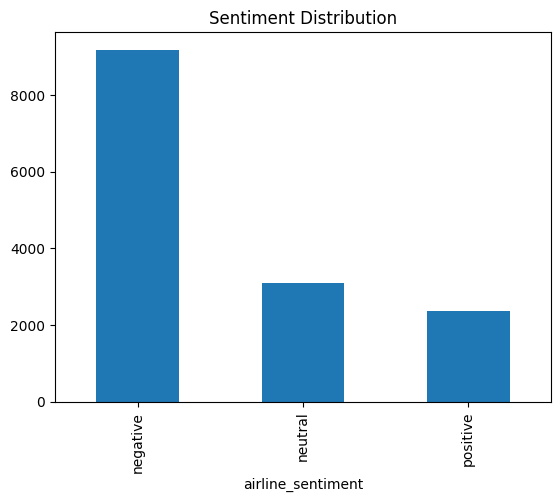

In [21]:
import matplotlib.pyplot as plt

df['airline_sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

In [22]:
df['length'] = df['text'].apply(lambda x: len(x.split()))
df['length'].describe()

count    14640.000000
mean        17.653415
std          6.882259
min          2.000000
25%         12.000000
50%         19.000000
75%         23.000000
max         36.000000
Name: length, dtype: float64

In [23]:
from src.preprocessing.clean_text import clean_text
df["cleaned_text"] = df["text"].apply(clean_text)
df.head()

,text,airline_sentiment,length,cleaned_text
0,@VirginAmerica What @dhepburn said.,neutral,4,what said
1,@VirginAmerica plus you've added commercials t...,positive,9,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,neutral,12,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,negative,17,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,negative,10,and its a really big bad thing about it


In [24]:
from src.preprocessing.tokenizer import build_vocab, texts_to_sequences

vocab = build_vocab(df["cleaned_text"], max_size=10000)

sequences = texts_to_sequences(df["cleaned_text"], vocab)

print(df["cleaned_text"].iloc[0])
print(sequences[0])

lengths = [len(seq) for seq in sequences]

print("Max length:", max(lengths))
print("Average length:", sum(lengths)/len(lengths))

what said
[52, 211]
Max length: 31
Average length: 15.933743169398907


In [25]:
from src.preprocessing.pad_sequence import pad_sequences

MAX_LEN = 31  # choose based on your analysis

padded_sequences = pad_sequences(sequences, MAX_LEN)

print(padded_sequences[0])
print(len(padded_sequences[0]))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 52, 211]
31


In [26]:
# lable maping
lable = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
df["label"] = df["airline_sentiment"].map(lable)

# convert to tensor
import torch

X = torch.tensor(padded_sequences, dtype=torch.long)
y = torch.tensor(df["label"].values, dtype=torch.long)

# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
# innitialize model
from src.model.lstm_model import LSTMModel

vocab_size = len(vocab) + 1
embed_dim = 128
hidden_dim = 128
output_dim = 3

model = LSTMModel(vocab_size, embed_dim, hidden_dim, output_dim)

sample_out = model(X_train[:4])
print(sample_out.shape)

torch.Size([4, 3])


In [28]:
# dataLoder
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [34]:
# train
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}, Loss: {avg_loss}")

Epoch 1, Loss: 0.18947574113561808
Epoch 2, Loss: 0.12640815407363443
Epoch 3, Loss: 0.08939102526163795
Epoch 4, Loss: 0.07522950795748846
Epoch 5, Loss: 0.04844613832833826


In [36]:
# evalution
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print("Test Accuracy:", accuracy*100, "%")

Test Accuracy: 77.83469945355192 %


In [31]:
# model evalution
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

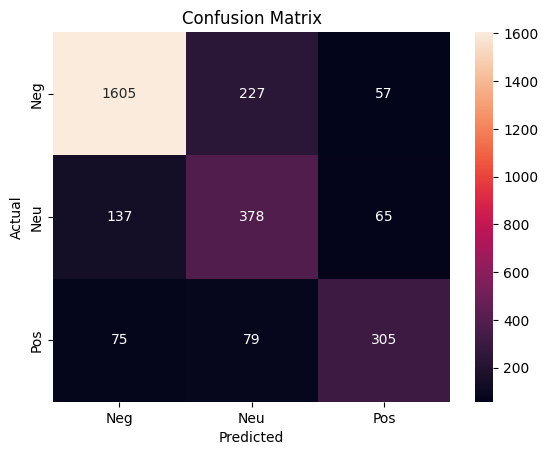

In [32]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Neg", "Neu", "Pos"],
            yticklabels=["Neg", "Neu", "Pos"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=["Negative", "Neutral", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87      1889
     Neutral       0.55      0.65      0.60       580
    Positive       0.71      0.66      0.69       459

    accuracy                           0.78      2928
   macro avg       0.72      0.72      0.72      2928
weighted avg       0.79      0.78      0.79      2928

